In [367]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Permutation testing

1. Generate observations for conditions a & b
2. Calculate the difference in means of distributions a & b
3. Combing observations into 1 vector
4. Create separate vector of condition labels for the combined conditions
5. Calculate a distribution of mean differences with 1000 iterations of the following
- Randomly assign conditions a & b to the combined observations
- Calculate the difference of means between the newly assigned distributions
6. Compute the probability of the mean diff of a & b, given the distribution of mean differences

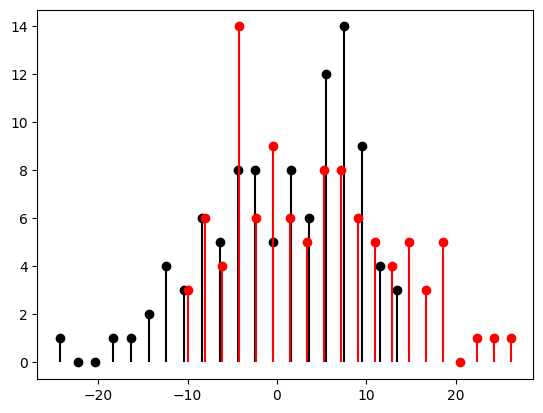

In [368]:
# 1. Generate observations for conditions a & b

# Number of trials
n = 100
variance = 10
shift = 2

random_samples = np.random.randn(n)
random_samples[random_samples>0] = np.log(1+random_samples[random_samples>0])
data_a = shift + random_samples * variance

random_samples = np.random.randn(n)
random_samples[random_samples>0] = np.log(1+random_samples[random_samples>0])
data_b = shift - random_samples * variance

ya, xa = np.histogram(data_a, 20)
xa = (xa[:-1]+xa[1:])/2

yb, xb = np.histogram(data_b, 20)
xb = (xb[:-1]+xb[1:])/2

fig_a, ax_a = plt.subplots()

ax_a.stem(xa, ya, 'ko', basefmt=' ',  label="Data A")
ax_a.stem(xb, yb, 'ro', basefmt=' ',  label="Data B")

fig_a.show()

In [369]:
# Permutation Testing

def permutation(data):
    rand_conditions = np.array([np.random.randint(2) for _ in data])
    pop_mean = np.mean(data[rand_conditions == 1]) - np.mean(data[rand_conditions == 0])
    return pop_mean

def permutation_test(data, permutations = 1000):
    if permutations <= 1:
        return permutation(data)
    else:
        return np.hstack((permutation(data), permutation_test(data, permutations - 1)))


## two methods of evaluating statistical significance

# # Z-value
# zVal = ( obsval-np.mean(permdiffs) ) / np.std(permdiffs,ddof=1)
# p = 1-stats.norm.cdf(abs(zVal))
#
# # p-value count
# pCount = sum(permdiffs>obsval)/nPerms
#
# print(p,pCount)

# Calculate probability
# Z-scale
z = lambda observed_diff, permutation_diffs: (observed_diff - np.mean(permutation_diffs)) / np.std(permutation_diffs, ddof=1)
p = lambda z: 1 - stats.norm.cdf(abs(z))

# Count
def prob_count(observed_mean, means_dist):
    total = np.sum(means_dist[means_dist >= abs(observed_mean)])
    return total / means_dist.size

11.540470415584398


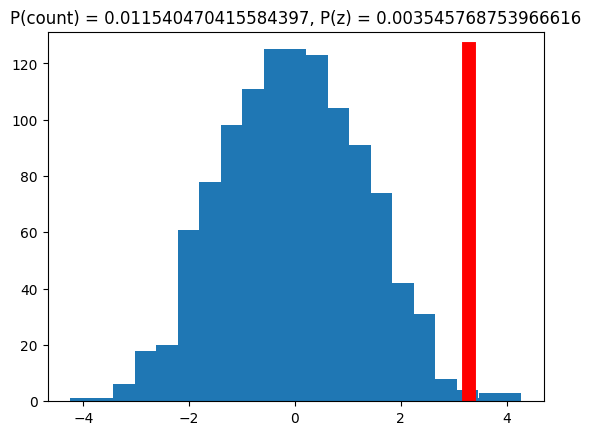

In [370]:
# 2. Calculate the difference in means of distributions a & b
# 3. Combing observations into 1 vector
# 4. Create separate vector of condition labels for the combined conditions

samples = np.hstack((data_a, data_b))
sample_conditions = np.hstack((np.zeros(len(data_a)), np.ones(len(data_b))))
mean_diff = np.mean(samples[sample_conditions == 1]) - np.mean(samples[sample_conditions == 0])

mean_distribution = permutation_test(samples)

prob_z = p(z(mean_diff, mean_distribution))
prob_count = prob_count(mean_diff, mean_distribution)

fig_b, ax_b = plt.subplots()

y, x = np.histogram(mean_distribution, 20)
x = (x[:-1]+x[1:])/2

ax_b.bar(x, y)
ax_b.plot([mean_diff, mean_diff], [np.min(y), np.max(y)], 'r', linewidth=10)
ax_b.set_title(f"P(count) = {prob_count}, P(z) = {prob_z}")

fig_b.show()

In [371]:


print(p(z(mean_diff, mean_distribution)))



0.003545768753966616
